# PETRA III measured-ORM fit
This tutorial fits a real PETRA III orbit-response measurement. The Python script is the compact reproducible counterpart; here the workflow is separated into physical steps.

## 1. Load the configuration and measurement
The YAML file names the lattice, machine data, rejected BPM positions, RF settings, fit parameters, and iteration controls.

In [2]:
from pathlib import Path
from petra_workflow import (HERE, load_yaml, make_plots, model_orm, prepare_measurement, print_summary, run_fit)
config_path = HERE / 'pyloco_config.yaml'
cfg = load_yaml(config_path)
data = prepare_measurement(config_path)

## 2. Inspect the measurement selection
Bad BPMs are identified by their positions in the ordered BPM-name list. Their horizontal and vertical rows, uncertainties, and dispersion entries are removed together.

In [3]:
print('Measured ORM:', data['orm'].shape)
print('BPMs per plane:', len(data['bpms']))
print('Correctors (H, V):', tuple(map(len, data['correctors'])))
print('Removed BPM positions:', cfg['bad_bpm_positions'])

Measured ORM: (470, 413)
BPMs per plane: 235
Correctors (H, V): (219, 194)
Removed BPM positions: [24, 104, 108, 111, 123, 138, 144, 153, 161, 162, 243]


## 3. Calculate the initial model ORM
The model uses the same BPMs, correctors, and kick amplitudes as the measurement. Its residual shows what the fit must explain.

In [4]:
initial_orm = model_orm(data)
print('Initial ORM:', initial_orm.shape)

Initial ORM: (470, 413)


## 4. Run pyLOCO
The standard workflow fits normal quadrupoles, BPM gains, corrector calibrations, and horizontal corrector energy shifts. `FitInitConfig` comes from `pyLOCO.config`. Jacobians use singular-value decomposition internally; the threshold is controlled in YAML.

In [5]:
fit = run_fit(data, coupling=False)
print('Iterations:', len(fit['chi2']))
print('Fitted blocks:', fit['fit_list'])


==== Iteration 1/1 – LM ====
[Jacobian] Computing normal-quadrupole Jacobian (iteration 1)...
[calculate_quads_jacobian] Logs saved to '/private/var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_petra_orm_0oco5xi1/logs/quad_jacobian_logs2.txt'
Normal quad Jacobian: 43.2 s
[Jacobian] Saved normal-quadrupole Jacobian to /var/folders/vj/crrgrwws3s902yfns0l06_rw0000gp/T/pyloco_petra_orm_0oco5xi1/jacobians/quads/J_quads_iter1_9.868774242500396e-05urad_-3000.0Hz.h5
   No outliers in the data set.
Initial Chi²: 2.4559e+04
  LM inner 1: chi² 6.5528e+02 (previous 2.4559e+04), λ=0.001
Chi² after correction: 6.5528e+02
LOCO LM completed! :).
Iterations: 1
Fitted blocks: ['quads', 'hbpm_gain', 'vbpm_gain', 'hcor_cal', 'vcor_cal', 'HCMEnergyShift']


## 5. Validate the fitted model
A successful fit reduces the measured ORM residual and normalized chi-square. Beta beating shows how the fitted lattice differs from the starting model.

Saved: /Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/measured_orm/orm_residual_before_after.png


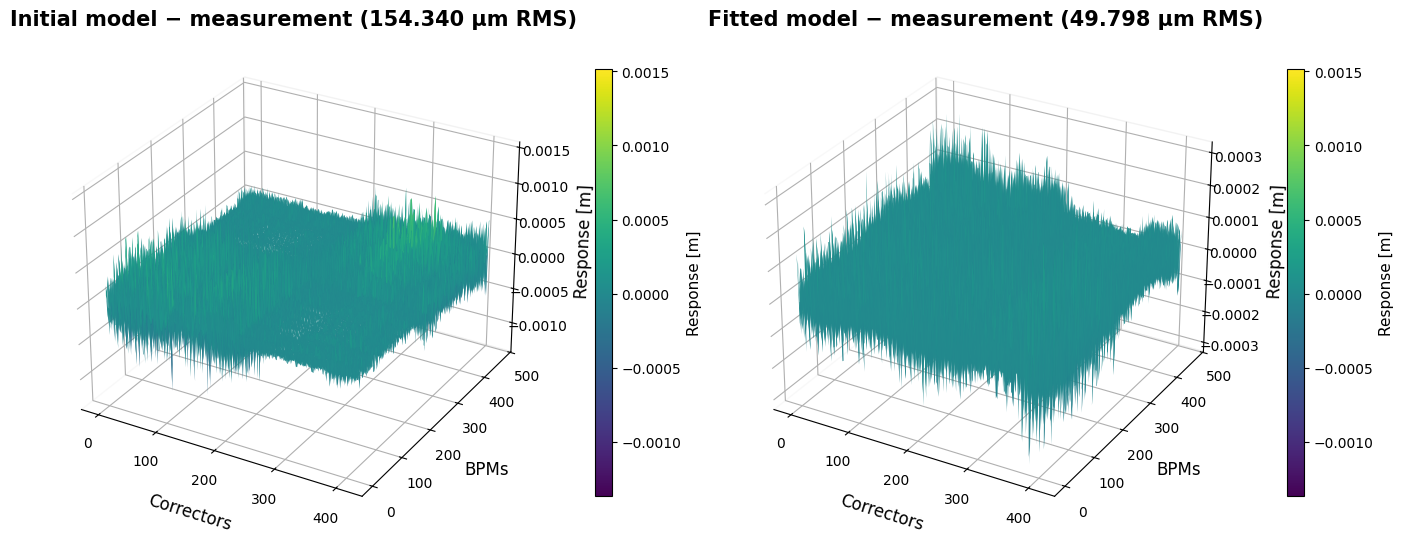


PETRA III measured-ORM fit
----------------------------------------------
Measured ORM shape : (470, 413)
Retained BPMs      : 235 per plane
Correctors         : 219 H, 194 V
Fitted parameters  : quads, hbpm_gain, vbpm_gain, hcor_cal, vcor_cal, HCMEnergyShift
ORM RMS before     : 154.339739 µm
ORM RMS after      : 49.797795 µm
Improvement        : 3.099x
Figures: /Users/musa/Desktop/pyLOCO/Examples/PETRAIII/output/measured_orm


In [6]:
output = make_plots(data, initial_orm, fit, coupling=False)
print_summary(data, initial_orm, fit, coupling=False)
print('Figures:', output)